In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [3]:
diabetes_dataset = pd.read_csv('diabetes.csv')
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes_dataset.shape

(768, 9)

In [5]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:

diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


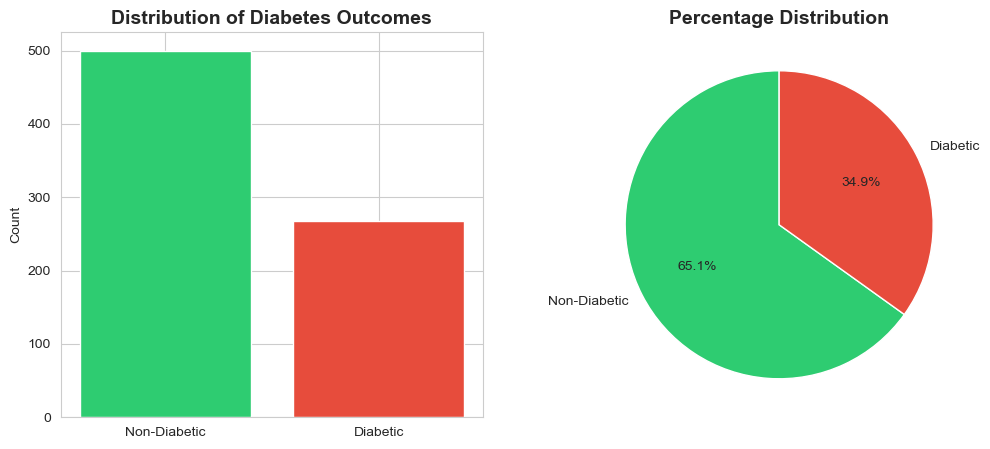

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
outcome_counts = diabetes_dataset['Outcome'].value_counts()
plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts.values, 
        color=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Diabetes Outcomes', fontsize=14, fontweight='bold')
plt.ylabel('Count')

plt.subplot(1,2,2)
plt.pie(outcome_counts.values, 
        labels=['Non-Diabetic', 'Diabetic'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],   # ✅ fixed here
        startangle=90)

plt.title('Percentage Distribution', fontsize=14, fontweight='bold')
plt.show()

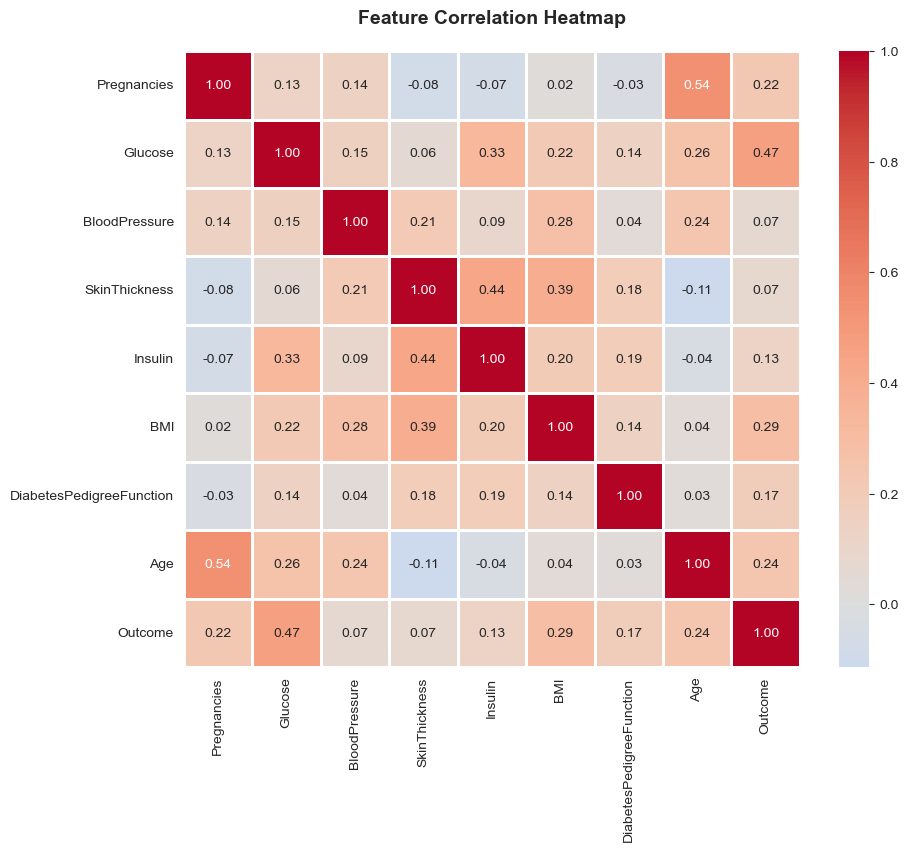

In [11]:
plt.figure(figsize=(10,8))

correlation = diabetes_dataset.corr()

sns.heatmap(correlation, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=1, 
            fmt='.2f')

plt.title('Feature Correlation Heatmap', fontsize=14, pad=20, fontweight='bold')
plt.show()

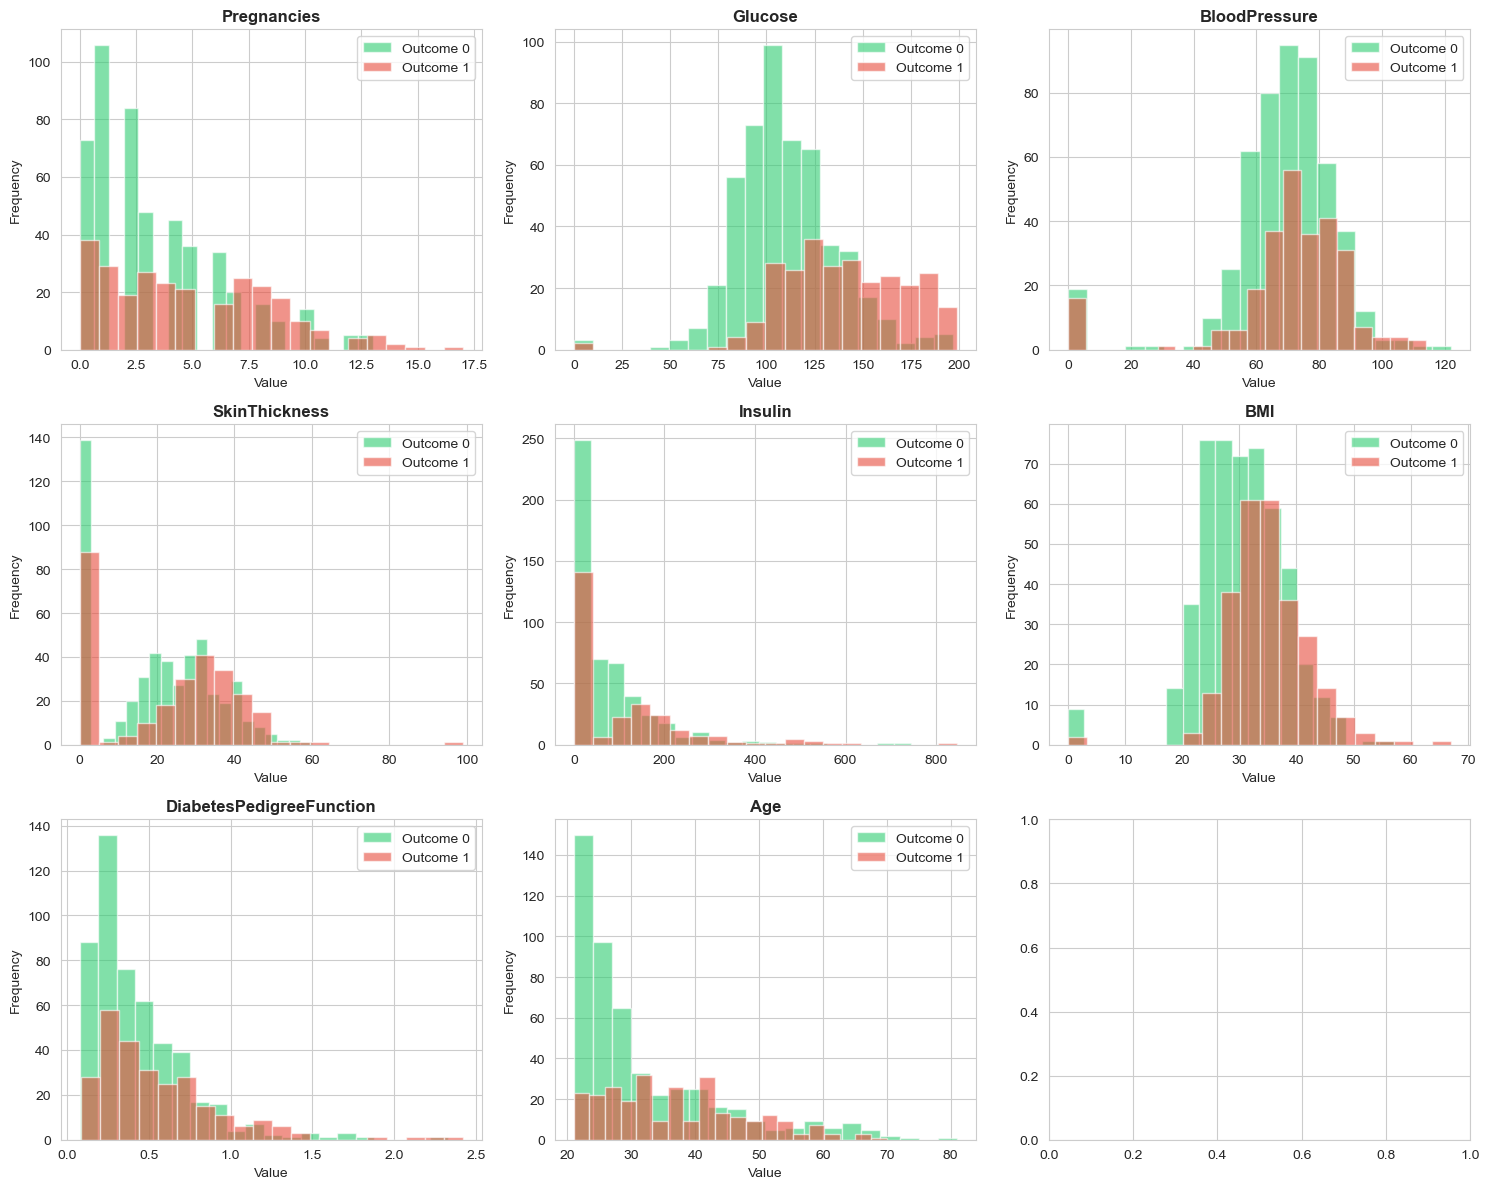

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

features = diabetes_dataset.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3
    
    for outcome in [0, 1]:
        data = diabetes_dataset[diabetes_dataset['Outcome'] == outcome][feature]
        
        axes[row, col].hist(
            data,
            alpha=0.6,
            bins=20,
            label=f'Outcome {outcome}',
            color=['#2ecc71', '#e74c3c'][outcome]
        )
    
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

In [14]:
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

print(X)
print(Y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(X)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [22]:
x_train, x_test, y_train, y_test = train_test_split(X, Y,test_size=0.2,stratify=Y,random_state=42)

print(X.shape, x_train.shape, x_test.shape)

(768, 8) (614, 8) (154, 8)


In [24]:
classifier = svm.SVC(kernel='linear', random_state=42)
classifier.fit(x_train, y_train)

SVC(kernel='linear', random_state=42)

In [25]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)

training_data_accuracy

0.7915309446254072

In [29]:
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)

test_data_accuracy

0.7207792207792207

In [30]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print(precision)
print(recall)
print(f1)

0.6222222222222222
0.5185185185185185
0.5656565656565656


In [34]:
cm_svm = confusion_matrix(y_test, x_test_prediction)

cm_svm

array([[83, 17],
       [26, 28]], dtype=int64)

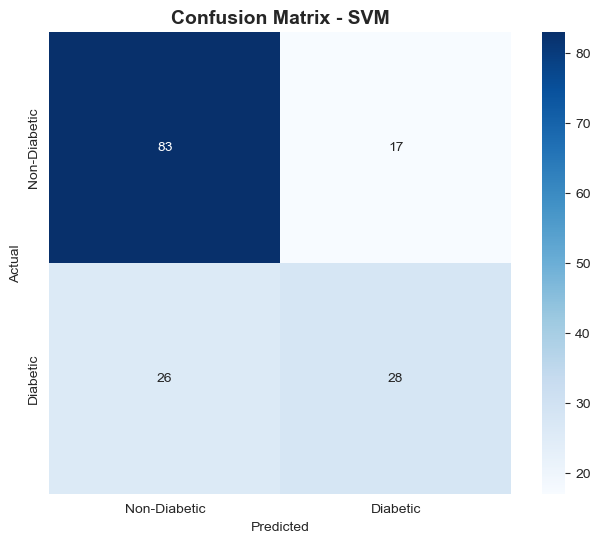

In [33]:
plt.figure(figsize=(8,6))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - SVM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [38]:
rf_classifier = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
x_train_prediction_rf = rf_classifier.predict(x_train)

In [40]:
training_data_accuracy_rf = accuracy_score(x_train_prediction_rf, y_train)

In [41]:
training_data_accuracy_rf = accuracy_score(x_train_prediction_rf, y_train)

training_data_accuracy_rf

1.0

In [42]:
x_test_prediction_rf = rf_classifier.predict(x_test)
test_data_accuracy_rf = accuracy_score(x_test_prediction_rf, y_test)

In [43]:
test_data_accuracy_rf

0.7532467532467533

In [44]:
precision_rf = precision_score(y_test, x_test_prediction_rf)

In [45]:
recall_rf = recall_score(y_test, x_test_prediction_rf)

In [46]:
f1_rf = f1_score(y_test, x_test_prediction_rf)

In [47]:
print(precision_rf)
print(recall_rf)
print(f1_rf)

0.66
0.6111111111111112
0.6346153846153846


In [49]:
cm_rf = confusion_matrix(y_test, x_test_prediction_rf)

cm_rf

array([[83, 17],
       [21, 33]], dtype=int64)

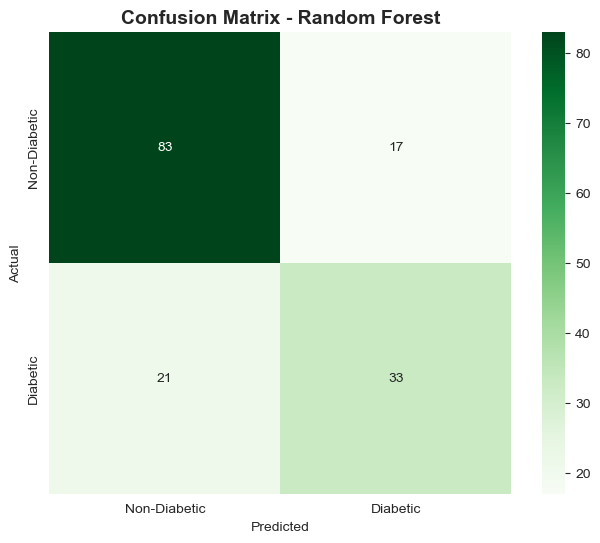

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Greens',square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [52]:
print('SVM', test_data_accuracy)
print('Random Forest', test_data_accuracy_rf)

SVM 0.7207792207792207
Random Forest 0.7532467532467533


In [53]:
joblib.dump(classifier, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [54]:
input_data = (5,166,72,19,175,25.8,0.587,51)
input_num_array = np.asarray(input_data)
reshape = input_num_array.reshape(1,-1)

std_data = scaler.transform(reshape)
prediction = classifier.predict(std_data)

In [55]:
prediction

array([1], dtype=int64)

In [57]:
joblib.dump(scaler, 'scaler_svm.pkl')

['scaler_svm.pkl']